# Project 5B: Flow Matching from Scratch!
<p style="color: red;"><strong>Note:</strong> You are not required to use the exact .ipynb notebook
         +or format (e.g., you can use a .py or modify the .ipynb however you wish). We only need to see the required deliverables / visualizations.</p>

## Setup environment

In [1]:
# We recommend using these utils.
# https://google.github.io/mediapy/mediapy.html
# https://einops.rocks/
!pip install mediapy einops --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 88.5 MB/s eta 0:00:00


In [2]:
# Import essential modules. Feel free to add whatever you need.
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from tqdm import tqdm

In [3]:
# Mount Google Drive for checkpointing
from google.colab import drive
from google.colab import files
drive.mount('/content/drive')
import os
import torchvision
import torchvision.transforms as transforms

Mounted at /content/drive


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Neural Network Resources

In this part, you will build and train a [UNet](https://arxiv.org/abs/1505.04597), which is more complex than the MLP you implemented in the NeRF project.  We provide all class definitions you may need (but feel free to add or modify them as necessary).  

Instead of asking ChatGPT to write everything for you, please consult the following resources when you get stuck — they will help you understand how and why things work under the hood.

- PyTorch Documentation — [`Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), [`ConvTranspose2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html), and [`AvgPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html).
- PyTorch Documentation - [`torchvision.datasets.MNIST`](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html), the dataset we gonna use, and [`torch.utils.data.DataLoader`](https://docs.pytorch.org/docs/stable/data.html), the off-the-shell dataloader we can directly use.
- PyTorch [tutorial](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) on how to train a classifier on CIFAR10 dataset. The structure of your training code will be very similar to this one.

# Part 1: Training a Single-step Denoising UNet


# Part 1.1: Implementing the UNet

## Implementing Simple and Composed Ops

In [10]:
class Conv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class DownConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class UpConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.AvgPool2d(kernel_size=7),
            nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Unflatten(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_channels, in_channels, kernel_size=7, stride=7, padding=0),
            nn.BatchNorm2d(in_channels),
            nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            Conv(in_channels, out_channels),
            Conv(out_channels, out_channels)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.down_conv = DownConv(in_channels, out_channels)
        self.conv_block = ConvBlock(out_channels, out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv_block(self.down_conv(x))


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.up_conv = UpConv(in_channels, out_channels)
        self.conv_block = ConvBlock(out_channels, out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv_block(self.up_conv(x))

## Implementing Unconditional UNet

In [11]:
class UnconditionalUNet(nn.Module):
    def __init__(self, in_channels: int, num_hiddens: int):
        super().__init__()
        D = num_hiddens

        # Encoder
        self.conv1   = ConvBlock(in_channels, D)   # 1x28x28  -> Dx28x28
        self.down1   = DownBlock(D, D)              # Dx28x28  -> Dx14x14
        self.down2   = DownBlock(D, 2*D)            # Dx14x14  -> 2Dx7x7
        self.flatten = Flatten()                    # 2Dx7x7   -> 2Dx1x1

        # Decoder
        self.unflatten = Unflatten(2*D)             # 2Dx1x1   -> 2Dx7x7
        self.up1       = UpBlock(2*D + 2*D, D)     # 4Dx7x7   -> Dx14x14
        self.up2       = UpBlock(D + D, D)          # 2Dx14x14 -> Dx28x28
        self.conv2     = ConvBlock(D + D, D)        # 2Dx28x28 -> Dx28x28
        self.out_conv  = nn.Conv2d(D, in_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."

        # Encoder
        s1 = self.conv1(x)     # (N, D,  28, 28)
        s2 = self.down1(s1)    # (N, D,  14, 14)
        s3 = self.down2(s2)    # (N, 2D,  7,  7)
        b  = self.flatten(s3)  # (N, 2D,  1,  1)

        # Decoder
        u = self.unflatten(b)                      # (N, 2D,  7,  7)
        u = self.up1(torch.cat([u,  s3], dim=1))  # (N,  D, 14, 14)
        u = self.up2(torch.cat([u,  s2], dim=1))  # (N,  D, 28, 28)
        u = self.conv2(torch.cat([u, s1], dim=1)) # (N,  D, 28, 28)
        return self.out_conv(u)                    # (N,  1, 28, 28)

# Part 1.2: Using the UNet to Train a Denoiser

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.08MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.38MB/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

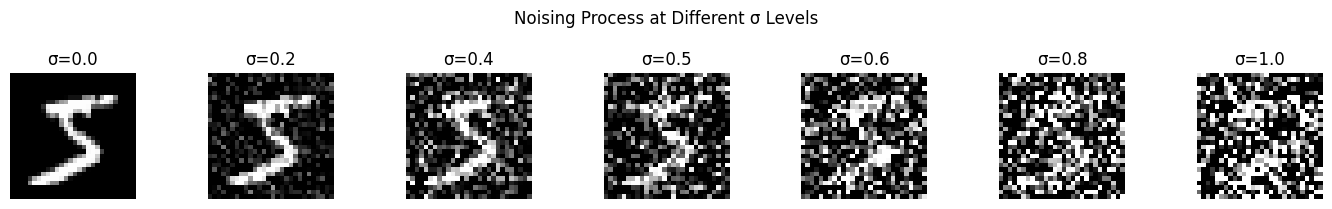

In [ ]:
# Visualize images at different noisy level
# Load one MNIST image
dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True,
                                      transform=transforms.ToTensor())
x, _ = dataset[0]  # shape: (1, 28, 28)

sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

fig, axes = plt.subplots(1, len(sigmas), figsize=(14, 2))
for ax, sigma in zip(axes, sigmas):
    eps = torch.randn_like(x)
    z = x + sigma * eps
    ax.imshow(z.squeeze().clamp(0, 1), cmap='gray')
    ax.set_title(f'σ={sigma}')
    ax.axis('off')

plt.suptitle('Noising Process at Different σ Levels', y=1.02)
plt.tight_layout()

plt.savefig('1.2_noising_process.png', bbox_inches='tight', dpi=150)
plt.show()

files.download('1.2_noising_process.png')

## Part 1.2.1: Training

For this part, we provide some structure code for training. It is very basic, so feel free to change them or add your code. In later section we won't provide any training or visualization structure code.

In [ ]:
device = torch.device('cuda')

# Set your hyperparameters
# ===== your code here! ====
batch_size = 256
learning_rate = 1e-4
noise_level = 0.5
hidden_dim = 128
num_epochs = 5
# ===== end of code ====

In [ ]:
# Define your datasets and dataloaders
# ===== your code here! ====
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)
# ===== end of code ====

In [ ]:
# Define your model, optimizer, and loss
# ===== your code here! ====
model = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()
# ===== end of code ====

100%|██████████| 235/235 [00:45<00:00,  5.12it/s]


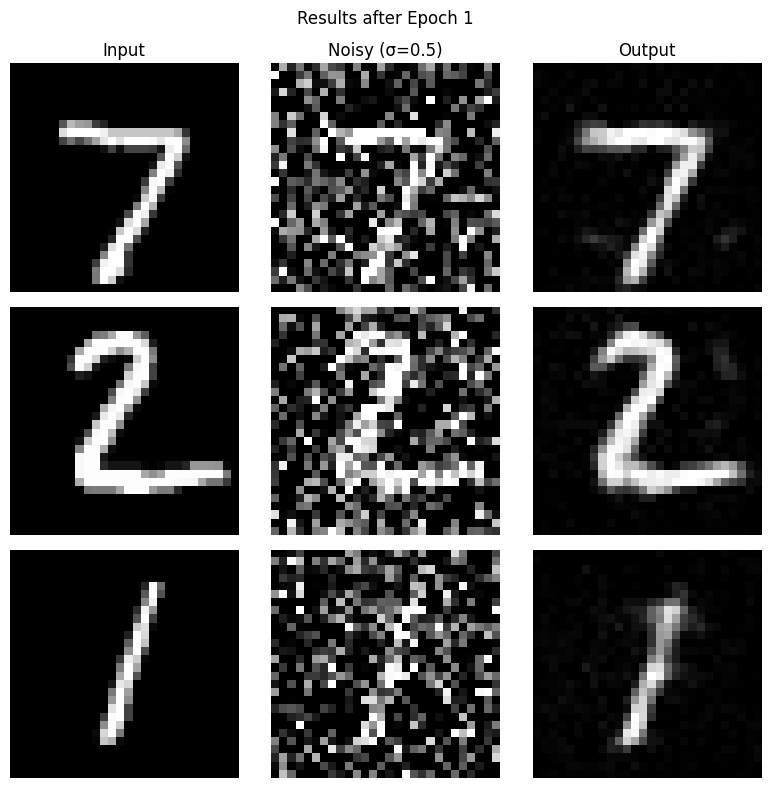

100%|██████████| 235/235 [00:45<00:00,  5.19it/s]


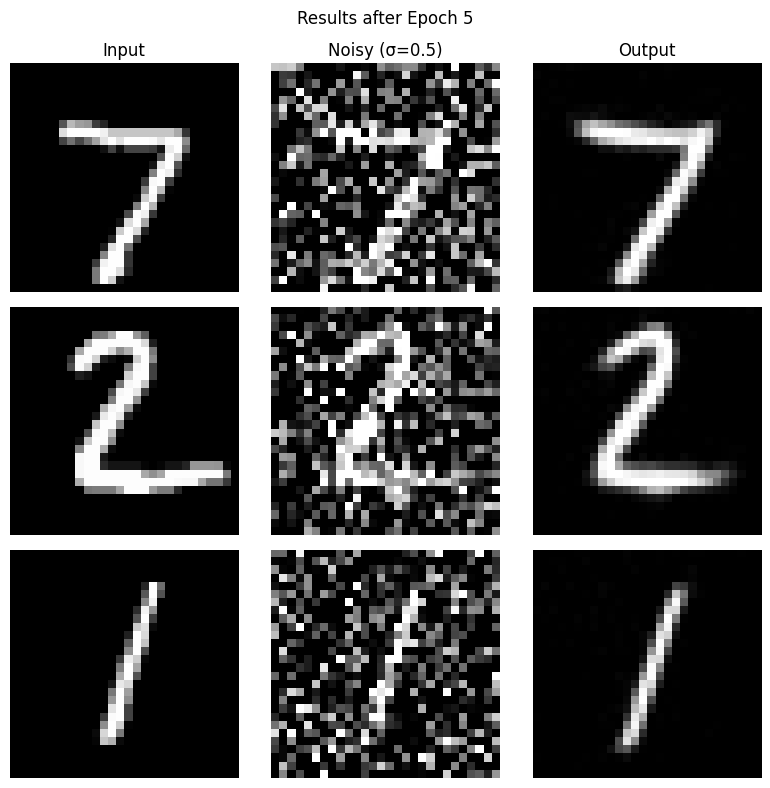

In [ ]:
# The training loop
train_losses = []
visualize_epochs = {1, num_epochs}  # visualize after epoch 1 and epoch 5

for epoch in range(1, num_epochs + 1):
    model.train()
    for i, (images, _) in enumerate(tqdm(train_loader)):
        images = images.to(device)

        # Add noise at training time (fresh noise each iteration)
        noise   = torch.randn_like(images)
        noisy   = images + noise_level * noise
        outputs = model(noisy)

        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    # Visualize sample results after epoch 1 and epoch 5
    if epoch in visualize_epochs:
        model.eval()
        with torch.no_grad():
            test_images, _ = next(iter(test_loader))
            test_images = test_images[:3].to(device)
            noisy_test  = test_images + noise_level * torch.randn_like(test_images)
            denoised    = model(noisy_test)

        fig, axes = plt.subplots(3, 3, figsize=(8, 8))
        col_titles = ['Input', f'Noisy (σ={noise_level})', 'Output']
        for col, title in enumerate(col_titles):
            axes[0][col].set_title(title)
        for row in range(3):
            for col, img in enumerate([test_images[row], noisy_test[row], denoised[row]]):
                axes[row][col].imshow(img.cpu().squeeze().clamp(0,1), cmap='gray')
                axes[row][col].axis('off')

        plt.suptitle(f'Results after Epoch {epoch}')
        plt.tight_layout()
        plt.savefig(f'denoising_epoch_{epoch}.png', bbox_inches='tight', dpi=150)
        plt.show()

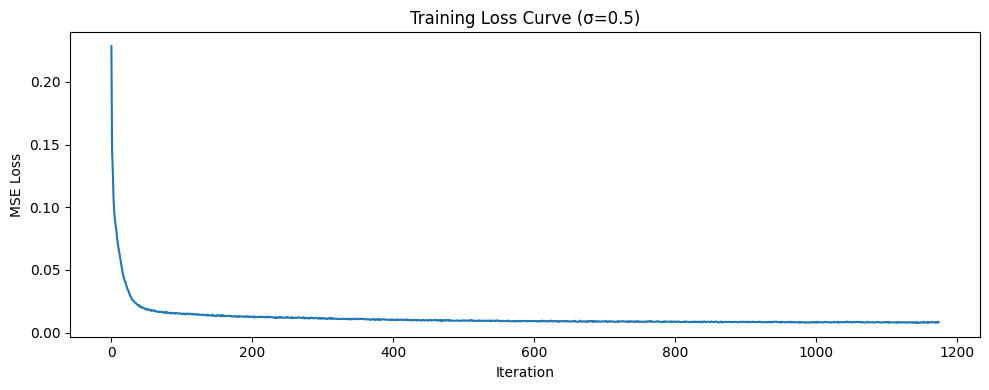

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Visualize your training curve
# ===== your code here! ====
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Training Loss Curve (σ=0.5)')
plt.tight_layout()
plt.savefig('1.2.1_training_loss_curve.png', bbox_inches='tight', dpi=150)
plt.show()

files.download('1.2.1_training_loss_curve.png')
# ===== end of code ====

In [ ]:
files.download('denoising_epoch_1.png')
files.download('denoising_epoch_5.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Part 1.2.2: Out-of-Distribution Testing

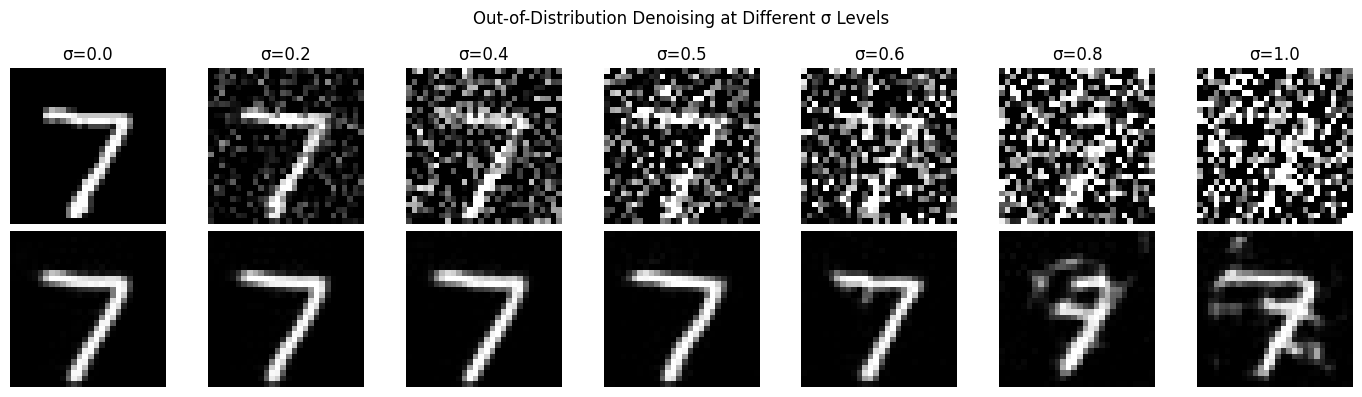

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Visualize OOD testing
sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

model.eval()
with torch.no_grad():
    # Get a single test image and repeat it for each sigma
    test_image, _ = test_dataset[0]
    test_image = test_image.unsqueeze(0).to(device)  # (1, 1, 28, 28)

    fig, axes = plt.subplots(2, len(sigmas), figsize=(14, 4))
    for col, sigma in enumerate(sigmas):
        noisy = test_image + sigma * torch.randn_like(test_image)
        denoised = model(noisy)

        axes[0][col].imshow(noisy.cpu().squeeze().clamp(0, 1), cmap='gray')
        axes[0][col].set_title(f'σ={sigma}')
        axes[0][col].axis('off')

        axes[1][col].imshow(denoised.cpu().squeeze().clamp(0, 1), cmap='gray')
        axes[1][col].axis('off')

    axes[0][0].set_ylabel('Noisy', fontsize=12)
    axes[1][0].set_ylabel('Denoised', fontsize=12)

plt.suptitle('Out-of-Distribution Denoising at Different σ Levels')
plt.tight_layout()
plt.savefig('1.2.2_ood_testing.png', bbox_inches='tight', dpi=150)
plt.show()

files.download('1.2.2_ood_testing.png')

## Part 1.2.3 Denoising Pure Noise

Mounted at /content/drive


100%|██████████| 235/235 [00:44<00:00,  5.25it/s]


Epoch 1 checkpointed.


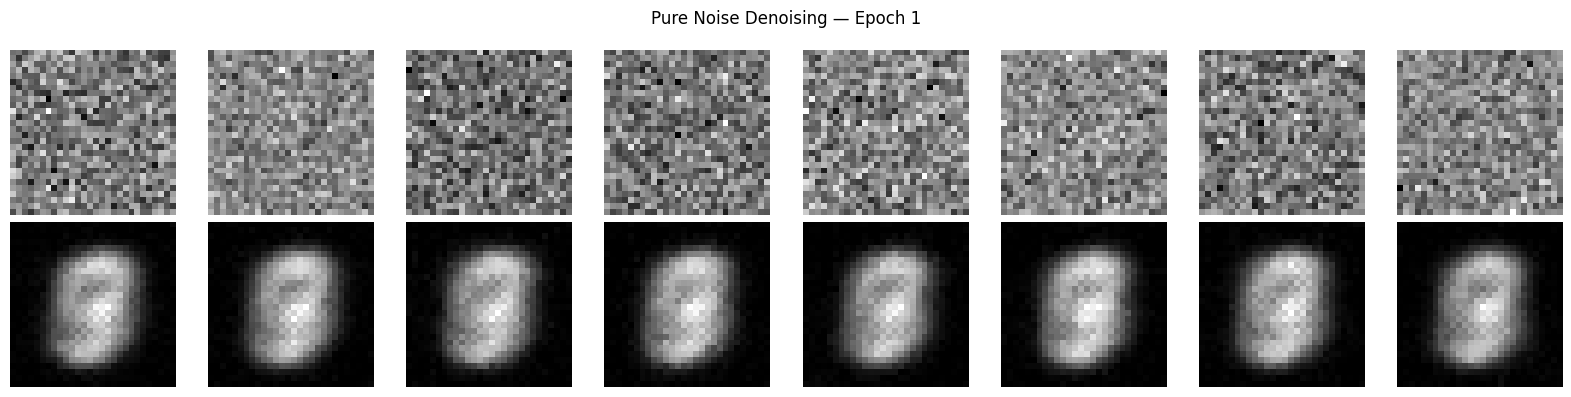

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

100%|██████████| 235/235 [00:44<00:00,  5.23it/s]


Epoch 2 checkpointed.


100%|██████████| 235/235 [00:45<00:00,  5.21it/s]


Epoch 3 checkpointed.


100%|██████████| 235/235 [00:45<00:00,  5.20it/s]


Epoch 4 checkpointed.


100%|██████████| 235/235 [00:45<00:00,  5.19it/s]


Epoch 5 checkpointed.


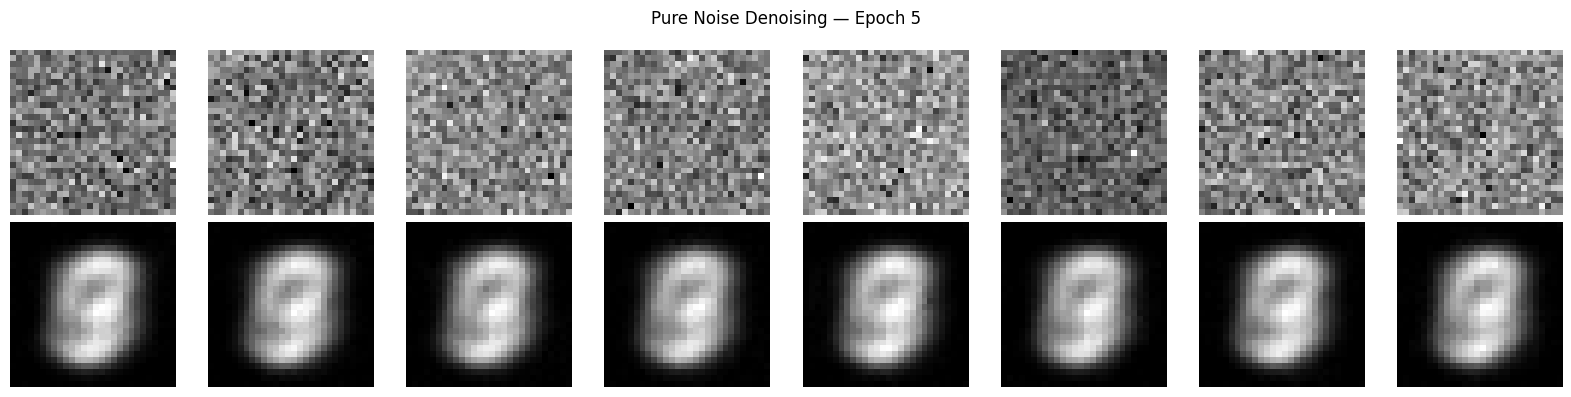

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

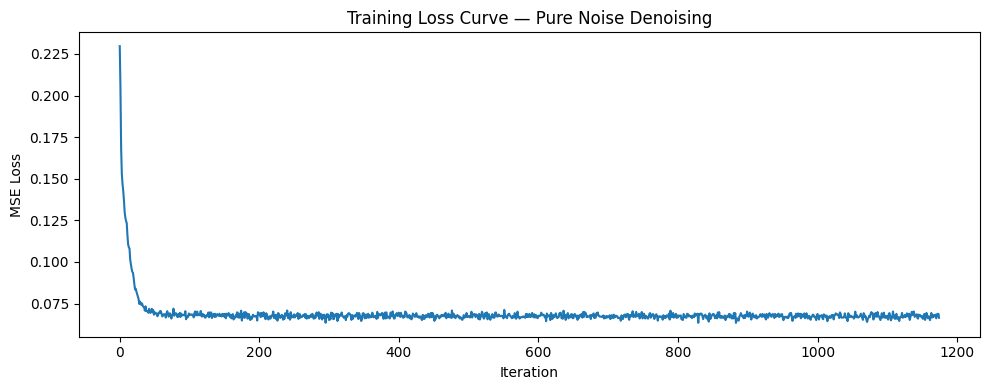

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
checkpoint_dir = '/content/drive/MyDrive/mnist_denoiser_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Fresh model for pure noise denoising
model_pure = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
optimizer_pure = torch.optim.Adam(model_pure.parameters(), lr=learning_rate)

# Resume from checkpoint if available
start_epoch = 1
latest_ckpt = os.path.join(checkpoint_dir, 'pure_noise_latest.pt')
if os.path.exists(latest_ckpt):
    ckpt = torch.load(latest_ckpt)
    model_pure.load_state_dict(ckpt['model'])
    optimizer_pure.load_state_dict(ckpt['optimizer'])
    start_epoch = ckpt['epoch'] + 1
    print(f"Resumed from epoch {ckpt['epoch']}")

# Training loop - input is pure noise, target is clean image
train_losses_pure = []
visualize_epochs = {1, num_epochs}

for epoch in range(start_epoch, num_epochs + 1):
    model_pure.train()
    for i, (images, _) in enumerate(tqdm(train_loader)):
        images = images.to(device)

        # Input is pure Gaussian noise, target is clean image
        pure_noise = torch.randn_like(images)
        outputs = model_pure(pure_noise)

        loss = criterion(outputs, images)
        optimizer_pure.zero_grad()
        loss.backward()
        optimizer_pure.step()

        train_losses_pure.append(loss.item())

    # Checkpoint every epoch to Google Drive
    torch.save({
        'epoch': epoch,
        'model': model_pure.state_dict(),
        'optimizer': optimizer_pure.state_dict(),
    }, latest_ckpt)
    print(f"Epoch {epoch} checkpointed.")

    # Visualize after epoch 1 and epoch 5
    if epoch in visualize_epochs:
        model_pure.eval()
        with torch.no_grad():
            # Sample by feeding pure noise
            sample_noise = torch.randn(8, 1, 28, 28).to(device)
            samples = model_pure(sample_noise)

        fig, axes = plt.subplots(2, 8, figsize=(16, 4))
        for col in range(8):
            axes[0][col].imshow(sample_noise[col].cpu().squeeze(), cmap='gray')
            axes[0][col].axis('off')
            axes[1][col].imshow(samples[col].cpu().squeeze().clamp(0,1), cmap='gray')
            axes[1][col].axis('off')

        axes[0][0].set_ylabel('Input\n(pure noise)', fontsize=9)
        axes[1][0].set_ylabel('Output\n(denoised)', fontsize=9)
        plt.suptitle(f'Pure Noise Denoising — Epoch {epoch}')
        plt.tight_layout()
        plt.savefig(f'1.2.3_pure_noise_epoch_{epoch}.png', bbox_inches='tight', dpi=150)
        plt.show()
        files.download(f'1.2.3_pure_noise_epoch_{epoch}.png')

# Plot training loss curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses_pure)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Training Loss Curve — Pure Noise Denoising')
plt.tight_layout()
plt.savefig('1.2.3_training_loss_pure_noise.png', bbox_inches='tight', dpi=150)
plt.show()
files.download('1.2.3_training_loss_pure_noise.png')

# Explanation for Patterns Observed

With MSE loss, the model learns to predict the mean of all training examples — the point that minimizes the sum of squared distances to every training image. Since the input is pure random noise with no information about which digit to generate, the model can't do better than outputting the average over all MNIST digits (0–9). The result is a blurry, blob-like shape that resembles the centroid of the digit distribution.
Key insight: This is a fundamental limitation of unconditional single-step generation with MSE loss — it produces mean-seeking, blurry outputs rather than sharp, diverse samples. This motivates the need for:

1. Conditioning (tell the model which digit to generate)

2. Iterative refinement (flow matching / diffusion)

# Part 2: Flow Matching

# Part 2.1: Implementing a Time-conditioned UNet

In [27]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_channels, out_channels),
            nn.GELU(),
            nn.Linear(out_channels, out_channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class TimeConditionalUNet(nn.Module):
    def __init__(self, in_channels: int, num_hiddens: int):
        super().__init__()
        D = num_hiddens

        # Time conditioning FCBlocks (scalar t -> D-dim embedding)
        # fc1_t conditions the unflatten (7x7 level), fc2_t conditions up1 (14x14 level)
        self.fc1_t = FCBlock(1, 2*D)   # modulates unflatten output (2D channels)
        self.fc2_t = FCBlock(1, D)     # modulates up1 output (D channels)

        # Encoder
        self.conv1    = ConvBlock(in_channels, D)   # 1x28x28  -> Dx28x28
        self.down1    = DownBlock(D, D)              # Dx28x28  -> Dx14x14
        self.down2    = DownBlock(D, 2*D)            # Dx14x14  -> 2Dx7x7
        self.flatten  = Flatten()                    # 2Dx7x7   -> 2Dx1x1

        # Decoder
        self.unflatten = Unflatten(2*D)              # 2Dx1x1   -> 2Dx7x7
        self.up1       = UpBlock(2*D + 2*D, D)      # 4Dx7x7   -> Dx14x14
        self.up2       = UpBlock(D + D, D)           # 2Dx14x14 -> Dx28x28
        self.conv2     = ConvBlock(D + D, D)         # 2Dx28x28 -> Dx28x28
        self.out_conv  = nn.Conv2d(D, in_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."

        # t: (N,) -> (N, 1) for FCBlock input
        t = t.view(-1, 1)

        # Compute time embeddings
        t1 = self.fc1_t(t)   # (N, 2D)
        t2 = self.fc2_t(t)   # (N, D)

        # Encoder
        s1 = self.conv1(x)     # (N, D,  28, 28)
        s2 = self.down1(s1)    # (N, D,  14, 14)
        s3 = self.down2(s2)    # (N, 2D,  7,  7)
        b  = self.flatten(s3)  # (N, 2D,  1,  1)

        # Decoder with time conditioning via scale modulation
        u = self.unflatten(b)                                          # (N, 2D, 7, 7)
        u = u * t1.view(-1, t1.shape[1], 1, 1)                        # modulate with t1
        u = self.up1(torch.cat([u, s3], dim=1))                        # (N, D,  14, 14)
        u = u * t2.view(-1, t2.shape[1], 1, 1)                        # modulate with t2
        u = self.up2(torch.cat([u, s2], dim=1))                        # (N, D,  28, 28)
        u = self.conv2(torch.cat([u, s1], dim=1))                      # (N, D,  28, 28)
        return self.out_conv(u)                                         # (N, 1,  28, 28)

## Implementing the Forward and Reverse Process for Time-conditioned Denoising

In [28]:
def time_fm_forward(
    unet: TimeConditionalUNet,
    x_1: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1

    Args:
        unet: TimeConditionalUNet
        x_1: (N, C, H, W) input tensor.
        num_ts: int, number of timesteps.
    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====
    N = x_1.shape[0]
    device = x_1.device

    # Sample x_0 ~ N(0, I) and t ~ Uniform[0, 1]
    x_0 = torch.randn_like(x_1)
    t   = torch.rand(N, device=device)  # (N,)

    # Linear interpolation: x_t = (1-t)*x_0 + t*x_1
    t_expanded = t.view(N, 1, 1, 1)
    x_t = (1 - t_expanded) * x_0 + t_expanded * x_1

    # Target flow: u(x_t, t) = x_1 - x_0
    target = x_1 - x_0

    # Predict flow and compute MSE loss
    pred = unet(x_t, t)
    loss = ((pred - target) ** 2).mean()
    return loss
    # ===== end of code ====

In [29]:
@torch.inference_mode()
def time_fm_sample(
    unet: TimeConditionalUNet,
    img_wh: tuple[int, int],
    num_ts: int,
    n_samples: int = 16,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2

    Args:
        unet: TimeConditionalUNet
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
    """
    unet.eval()
    # ===== your code here! ====
    device = next(unet.parameters()).device
    H, W = img_wh
    C = 1

    torch.manual_seed(seed)
    x_t = torch.randn(n_samples, C, H, W, device=device)  # x_0 ~ N(0, I)

    dt = 1.0 / num_ts
    for i in range(num_ts):
        t_val = i / num_ts
        t = torch.full((n_samples,), t_val, device=device)  # (N,)
        u = unet(x_t, t)                                     # predicted flow
        x_t = x_t + dt * u                                   # Euler step

    return x_t  # (N, C, H, W)
    # ===== end of code ====

In [30]:
class TimeConditionalFM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        num_ts: int = 50,
        img_hw: tuple[int, int] = (28, 28),
    ):
        super().__init__()

        self.unet = unet
        self.num_ts = num_ts
        self.img_hw = img_hw


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """
        return time_fm_forward(
            self.unet, x, self.num_ts
        )


    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        n_samples=16,
        seed: int = 0,
    ):
        return time_fm_sample(
            self.unet, img_wh, self.num_ts, n_samples=n_samples, seed=seed
        )

# Part 2.2: Training the Time-conditioned UNet

In [33]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
# Hyperparameters (reuse from 1.2.1, no noise_level needed)
batch_size    = 256
learning_rate = 1e-4
hidden_dim    = 128
num_epochs    = 10
num_ts        = 50

# Datasets and dataloaders (same as 1.2.1)
transform     = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader  = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader   = torch.utils.data.DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Model, optimizer
unet_fm   = TimeConditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
fm_model  = TimeConditionalFM(unet=unet_fm, num_ts=num_ts, img_hw=(28, 28)).to(device)
optimizer = torch.optim.Adam(fm_model.parameters(), lr=learning_rate)

# Checkpointing setup
checkpoint_dir = '/content/drive/MyDrive/mnist_fm_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
latest_ckpt = os.path.join(checkpoint_dir, 'fm_latest.pt')
# ===== end of code ====

100%|██████████| 235/235 [00:44<00:00,  5.23it/s]


Epoch 1 checkpointed.


100%|██████████| 235/235 [00:45<00:00,  5.20it/s]


Epoch 2 checkpointed.


100%|██████████| 235/235 [00:45<00:00,  5.22it/s]


...

Epoch 8 checkpointed.


100%|██████████| 235/235 [00:45<00:00,  5.21it/s]


Epoch 9 checkpointed.


100%|██████████| 235/235 [00:45<00:00,  5.20it/s]


Epoch 10 checkpointed.


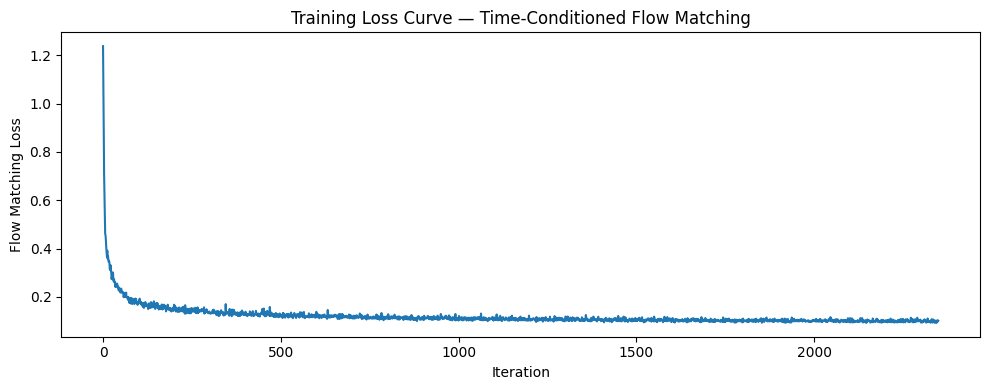

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
start_epoch = 1
# if os.path.exists(latest_ckpt):
#     ckpt = torch.load(latest_ckpt)
#     fm_model.load_state_dict(ckpt['model'])
#     optimizer.load_state_dict(ckpt['optimizer'])
#     start_epoch = ckpt['epoch'] + 1
#     print(f"Resumed from epoch {ckpt['epoch']}")

# Training loop
train_losses_fm = []
visualize_epochs = {1, 5, num_epochs}

for epoch in range(start_epoch, num_epochs + 1):
    fm_model.train()
    for i, (images, _) in enumerate(tqdm(train_loader)):
        images = images.to(device)

        # Forward pass computes flow matching loss internally
        loss = fm_model(images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses_fm.append(loss.item())

    # Checkpoint every epoch
    torch.save({
        'epoch': epoch,
        'model': fm_model.state_dict(),
        'optimizer': optimizer.state_dict(),
    }, latest_ckpt)
    print(f"Epoch {epoch} checkpointed.")

    if epoch in visualize_epochs:
      torch.save({
        'epoch': epoch,
        'model': fm_model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'losses': train_losses_fm,
      }, os.path.join(checkpoint_dir, f'fm_epoch_{epoch}.pt'))

# Plot training loss curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses_fm)
plt.xlabel('Iteration')
plt.ylabel('Flow Matching Loss')
plt.title('Training Loss Curve — Time-Conditioned Flow Matching')
plt.tight_layout()
plt.savefig('2.2_fm_training_loss.png', bbox_inches='tight', dpi=150)
plt.show()
files.download('2.2_fm_training_loss.png')

In [37]:
import os
checkpoint_dir = '/content/drive/MyDrive/mnist_fm_checkpoints'
print(os.listdir(checkpoint_dir))

['fm_epoch_1.pt', 'fm_epoch_5.pt', 'fm_epoch_10.pt', 'fm_latest.pt']


# Part 2.3: Sampling from the Time-conditioned UNet

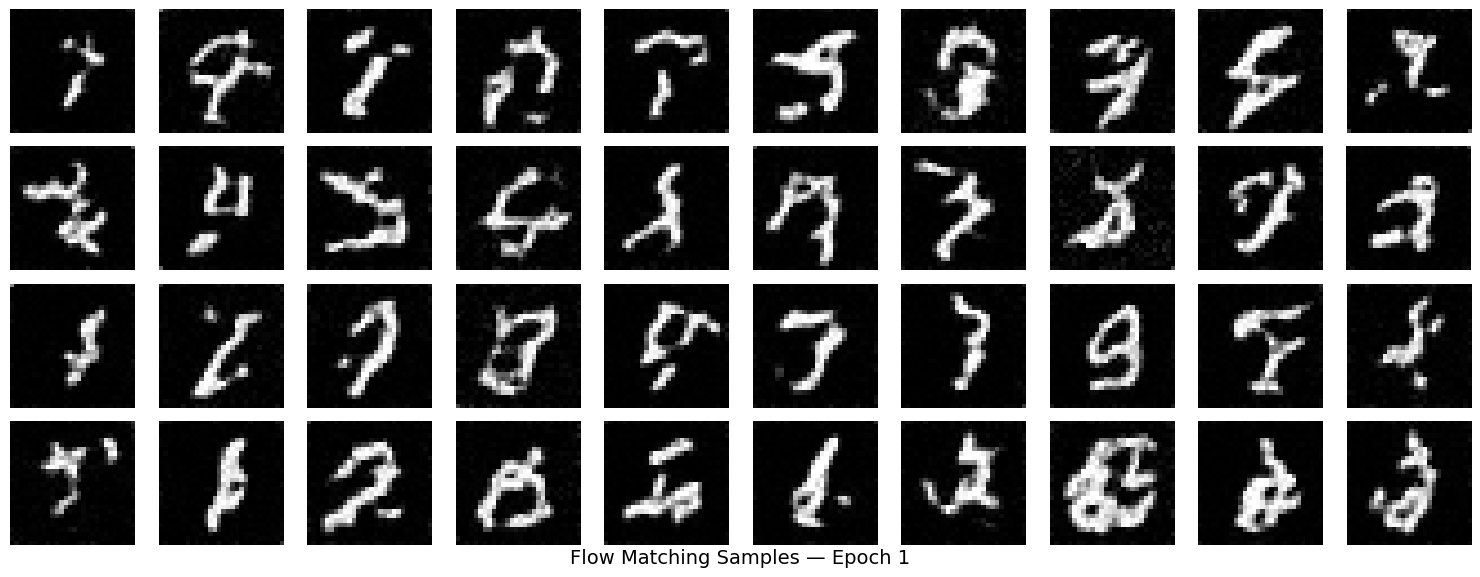

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

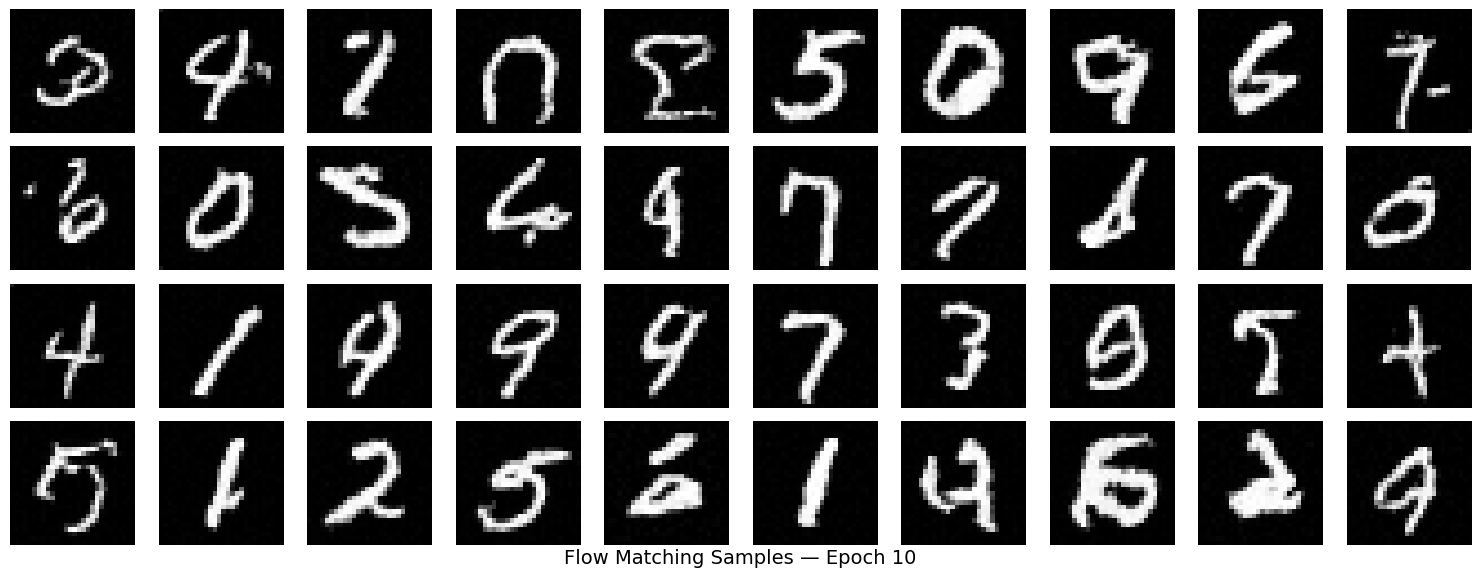

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

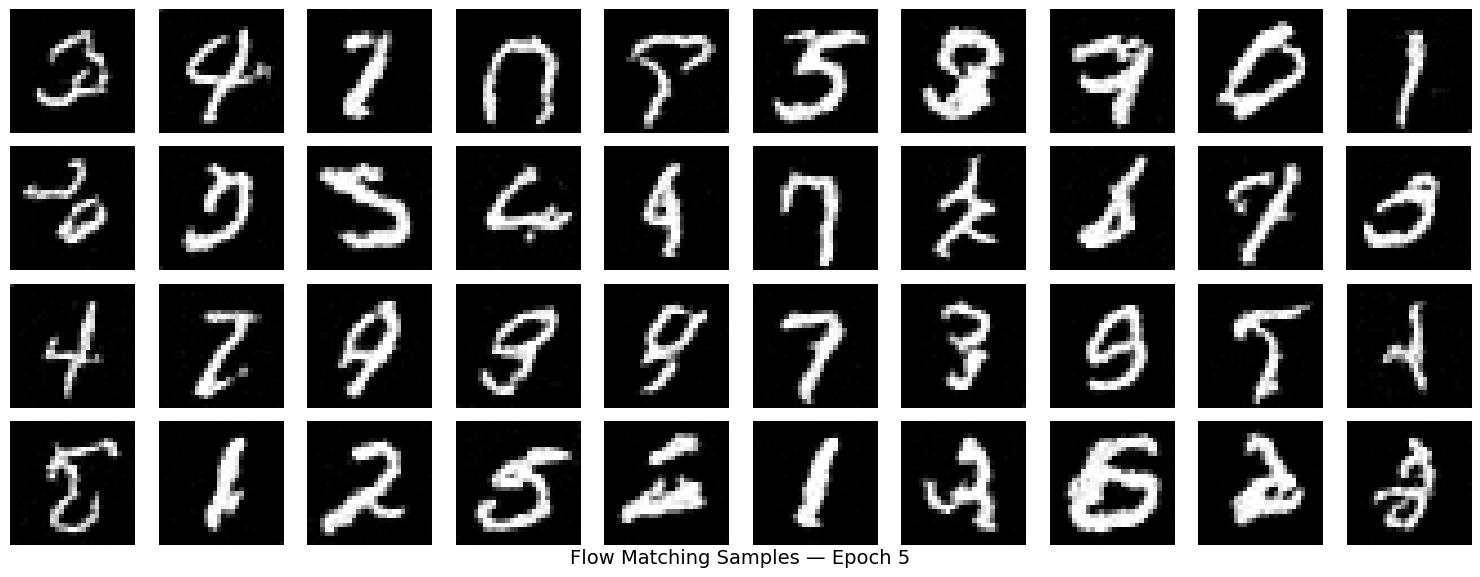

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
# Sampling from the UNet
# ===== your code here! ====
# Sampling from the UNet at different training epochs
for epoch in {1, 5, 10}:
    ckpt_path = os.path.join(checkpoint_dir, f'fm_epoch_{epoch}.pt')
    ckpt = torch.load(ckpt_path)
    fm_model.load_state_dict(ckpt['model'])

    samples = fm_model.sample(img_wh=(28, 28), n_samples=40, seed=0)

    fig, axes = plt.subplots(4, 10, figsize=(15, 6))
    for idx, ax in enumerate(axes.flatten()):
        ax.imshow(samples[idx].cpu().squeeze().clamp(0, 1), cmap='gray')
        ax.axis('off')

    plt.suptitle(f'Flow Matching Samples — Epoch {epoch}', y=0.02, fontsize=14)
    plt.tight_layout()
    plt.savefig(f'2.3_fm_samples_epoch_{epoch}.png', bbox_inches='tight', dpi=150)
    plt.show()
    files.download(f'2.3_fm_samples_epoch_{epoch}.png')
# ===== end of code ====

In [ ]:
# files.download('fm_samples_epoch_1.png')
# files.download('fm_samples_epoch_5.png')
# files.download('fm_samples_epoch_10.png')

# Part 2.4: Implementing a Class-conditioned UNet

In [17]:
class ClassConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        D = num_hiddens

        # Time conditioning FCBlocks
        self.fc1_t = FCBlock(1, 2*D)        # modulates unflatten (2D channels)
        self.fc2_t = FCBlock(1, D)          # modulates up1 (D channels)

        # Class conditioning FCBlocks (one-hot vector of size num_classes)
        self.fc1_c = FCBlock(num_classes, 2*D)
        self.fc2_c = FCBlock(num_classes, D)

        # Encoder
        self.conv1    = ConvBlock(in_channels, D)
        self.down1    = DownBlock(D, D)
        self.down2    = DownBlock(D, 2*D)
        self.flatten  = Flatten()

        # Decoder
        self.unflatten = Unflatten(2*D)
        self.up1       = UpBlock(2*D + 2*D, D)
        self.up2       = UpBlock(D + D, D)
        self.conv2     = ConvBlock(D + D, D)
        self.out_conv  = nn.Conv2d(D, in_channels, kernel_size=3, stride=1, padding=1)

        self.num_classes = num_classes
        # ===== end of code ====

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        N = x.shape[0]
        device = x.device

        # Convert class labels to one-hot
        c_onehot = torch.zeros(N, self.num_classes, device=device)
        c_onehot.scatter_(1, c.view(-1, 1), 1.0)

        # Apply classifier-free guidance dropout: zero out class conditioning
        if mask is not None:
            c_onehot = c_onehot * mask.view(-1, 1).float()

        # t: (N,) -> (N, 1)
        t = t.view(-1, 1)

        # Compute time and class embeddings
        t1 = self.fc1_t(t)         # (N, 2D)
        c1 = self.fc1_c(c_onehot)  # (N, 2D)
        t2 = self.fc2_t(t)         # (N, D)
        c2 = self.fc2_c(c_onehot)  # (N, D)

        # Encoder
        s1 = self.conv1(x)     # (N, D,  28, 28)
        s2 = self.down1(s1)    # (N, D,  14, 14)
        s3 = self.down2(s2)    # (N, 2D,  7,  7)
        b  = self.flatten(s3)  # (N, 2D,  1,  1)

        # Decoder with time + class conditioning
        u = self.unflatten(b)                                # (N, 2D, 7, 7)
        u = c1.view(N, -1, 1, 1) * u + t1.view(N, -1, 1, 1)  # modulate
        u = self.up1(torch.cat([u, s3], dim=1))              # (N, D, 14, 14)
        u = c2.view(N, -1, 1, 1) * u + t2.view(N, -1, 1, 1)  # modulate
        u = self.up2(torch.cat([u, s2], dim=1))              # (N, D, 28, 28)
        u = self.conv2(torch.cat([u, s1], dim=1))            # (N, D, 28, 28)
        return self.out_conv(u)                              # (N, 1, 28, 28)
        # ===== end of code ====

In [18]:
def class_fm_forward(
    unet: ClassConditionalUNet,
    x_1: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 3

    Args:
        unet: ClassConditionalUNet
        x_1: (N, C, H, W) input tensor.
        c: (N,) int64 condition tensor.
        p_uncond: float, probability of unconditioning the condition.
        num_ts: int, number of timesteps.

    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====
    N = x_1.shape[0]
    device = x_1.device

    # Sample x_0 ~ N(0, I) and t ~ Uniform[0, 1]
    x_0 = torch.randn_like(x_1)
    t   = torch.rand(N, device=device)

    # Linear interpolation: x_t = (1-t)*x_0 + t*x_1
    t_expanded = t.view(N, 1, 1, 1)
    x_t = (1 - t_expanded) * x_0 + t_expanded * x_1

    # Target flow: u(x_t, t) = x_1 - x_0
    target = x_1 - x_0

    # Classifier-free guidance dropout mask
    # mask=0 means drop class conditioning (unconditional), mask=1 means keep it
    mask = (torch.rand(N, device=device) >= p_uncond).long()  # (N,)

    # Predict flow and compute MSE loss
    pred = unet(x_t, c, t, mask=mask)
    loss = ((pred - target) ** 2).mean()
    return loss
    # ===== end of code ====

In [19]:
@torch.inference_mode()
def class_fm_sample(
    unet: ClassConditionalUNet,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 4

    Args:
        unet: ClassConditionalUNet
        c: (N,) int64 condition tensor. Only for class-conditional
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        guidance_scale: float, CFG scale.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) caches.
    """
    unet.eval()
    # ===== your code here! ====
    device = next(unet.parameters()).device
    H, W = img_wh
    N = c.shape[0]

    torch.manual_seed(seed)
    x_t = torch.randn(N, 1, H, W, device=device)  # x_0 ~ N(0, I)

    # Mask for conditional (all ones) and unconditional (all zeros)
    mask_cond   = torch.ones(N,  device=device).long()   # keep class conditioning
    mask_uncond = torch.zeros(N, device=device).long()   # drop class conditioning

    caches = []  # store intermediate states for animation

    dt = 1.0 / num_ts
    for i in range(num_ts):
        t_val = i / num_ts
        t = torch.full((N,), t_val, device=device)

        # Conditional and unconditional flow predictions
        u_cond   = unet(x_t, c, t, mask=mask_cond)    # conditional
        u_uncond = unet(x_t, c, t, mask=mask_uncond)  # unconditional

        # Classifier-free guidance
        u = u_uncond + guidance_scale * (u_cond - u_uncond)

        # Euler step
        x_t = x_t + dt * u

        caches.append(x_t.unsqueeze(1))  # (N, 1, C, H, W)

    caches = torch.cat(caches, dim=1)  # (N, T_animation, C, H, W)
    return x_t, caches
    # ===== end of code ====

In [20]:
class ClassConditionalFM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.p_uncond = p_uncond

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) loss.
        """
        return class_fm_forward(
            self.unet, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return class_fm_sample(
            self.unet, c, img_wh, self.num_ts, guidance_scale, seed
        )

# Part 2.5 Training the Class-conditioned UNet

In [21]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
# Hyperparameters
batch_size    = 256
learning_rate = 1e-4
hidden_dim    = 128
num_epochs    = 10
num_ts        = 50
num_classes   = 10
p_uncond      = 0.1

# Datasets and dataloaders (same as before)
transform     = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader  = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader   = torch.utils.data.DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Model, optimizer
unet_class = ClassConditionalUNet(in_channels=1, num_classes=num_classes, num_hiddens=hidden_dim).to(device)
optimizer  = torch.optim.Adam(unet_class.parameters(), lr=learning_rate)

# Checkpointing setup
checkpoint_dir_class = '/content/drive/MyDrive/mnist_class_fm_checkpoints'
os.makedirs(checkpoint_dir_class, exist_ok=True)
latest_ckpt_class = os.path.join(checkpoint_dir_class, 'class_fm_latest.pt')
# ===== end of code ====

100%|██████████| 235/235 [00:46<00:00,  5.10it/s]


Epoch 1 checkpointed.


100%|██████████| 235/235 [00:44<00:00,  5.23it/s]


Epoch 2 checkpointed.


100%|██████████| 235/235 [00:45<00:00,  5.18it/s]


...

Epoch 8 checkpointed.


100%|██████████| 235/235 [00:45<00:00,  5.20it/s]


Epoch 9 checkpointed.


100%|██████████| 235/235 [00:45<00:00,  5.18it/s]


Epoch 10 checkpointed.


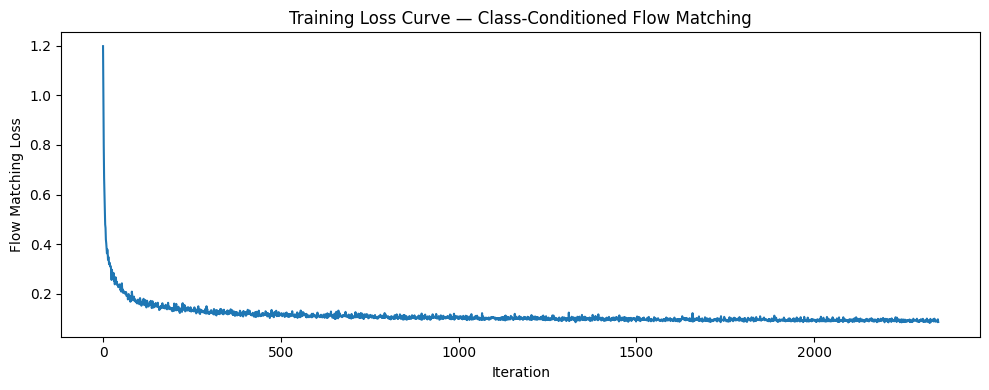

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
start_epoch = 1
if os.path.exists(latest_ckpt_class):
    ckpt = torch.load(latest_ckpt_class)
    unet_class.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    start_epoch = ckpt['epoch'] + 1
    print(f"Resumed from epoch {ckpt['epoch']}")

train_losses_class = []
visualize_epochs   = {1, 5, num_epochs}

for epoch in range(start_epoch, num_epochs + 1):
    unet_class.train()
    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)  # (N,) int64 class labels

        loss = class_fm_forward(unet_class, images, labels, p_uncond, num_ts)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses_class.append(loss.item())

    # Save latest checkpoint
    torch.save({
        'epoch': epoch,
        'model': unet_class.state_dict(),
        'optimizer': optimizer.state_dict(),
    }, latest_ckpt_class)
    print(f"Epoch {epoch} checkpointed.")

    # Save per-epoch checkpoint for visualization
    if epoch in visualize_epochs:
        torch.save({
            'epoch': epoch,
            'model': unet_class.state_dict(),
            'optimizer': optimizer.state_dict(),
            'losses': train_losses_class,
        }, os.path.join(checkpoint_dir_class, f'class_fm_epoch_{epoch}.pt'))

# Plot training loss curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses_class)
plt.xlabel('Iteration')
plt.ylabel('Flow Matching Loss')
plt.title('Training Loss Curve — Class-Conditioned Flow Matching')
plt.tight_layout()
plt.savefig('2.5_class_fm_training_loss.png', bbox_inches='tight', dpi=150)
plt.show()
files.download('2.5_class_fm_training_loss.png')

# Part 2.6: Sampling from the Class-conditioned UNet

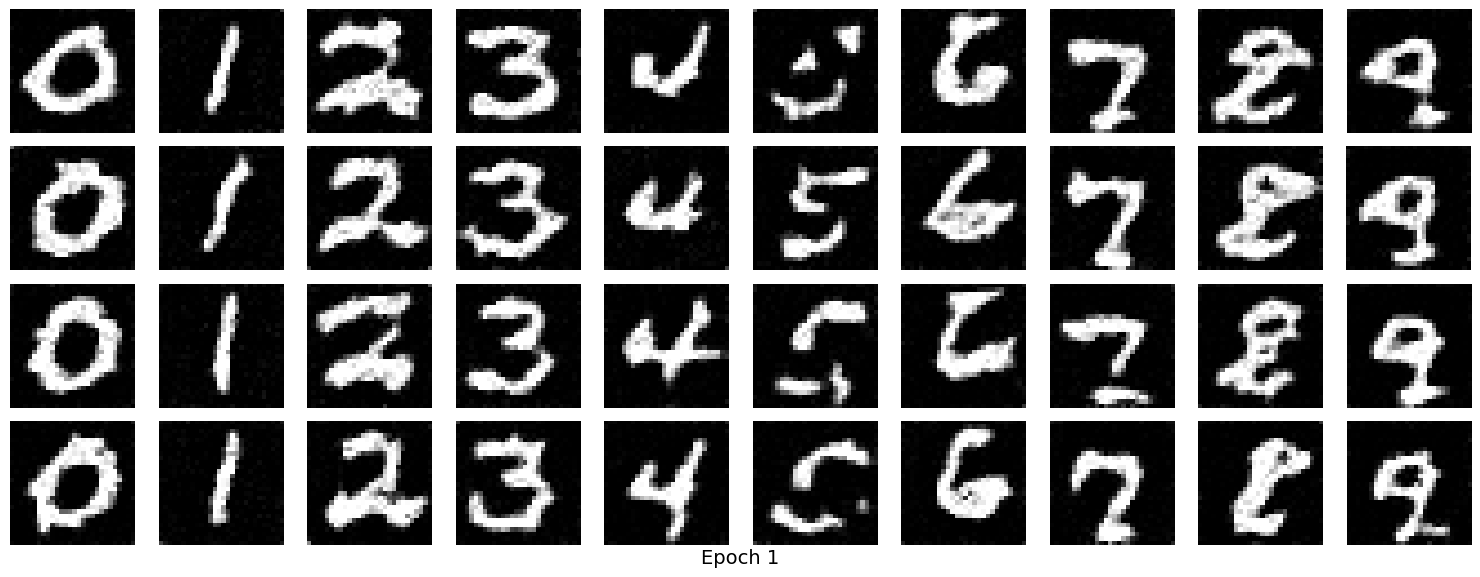

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

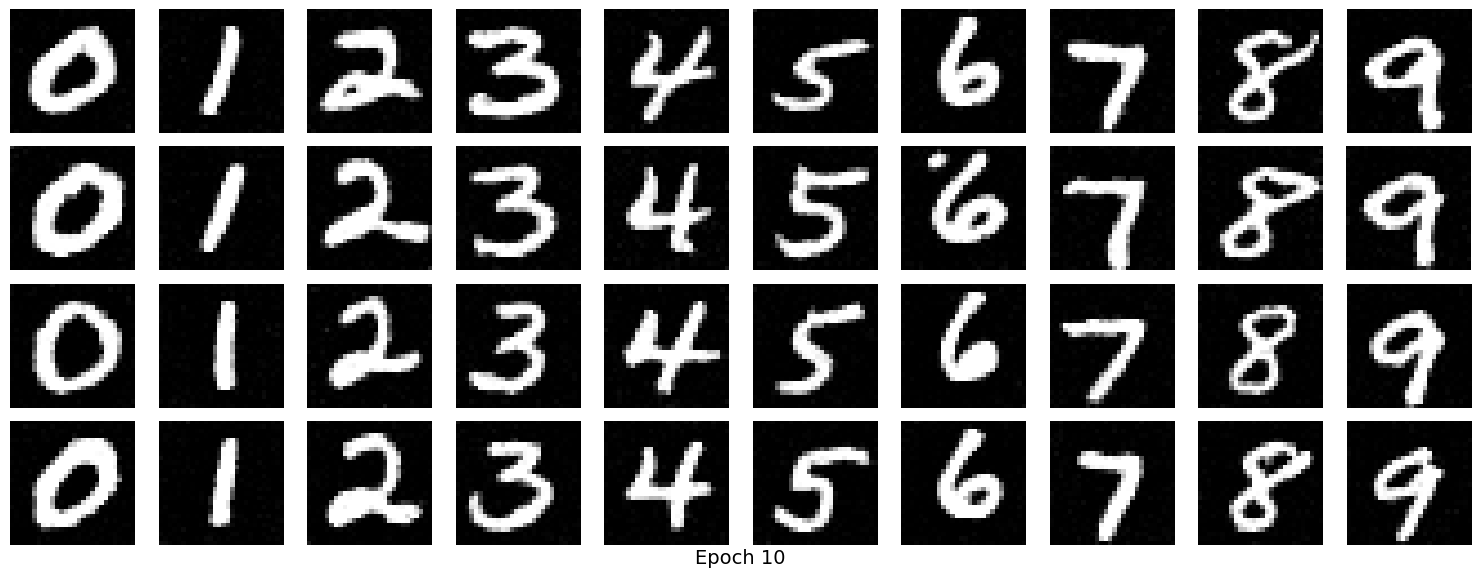

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

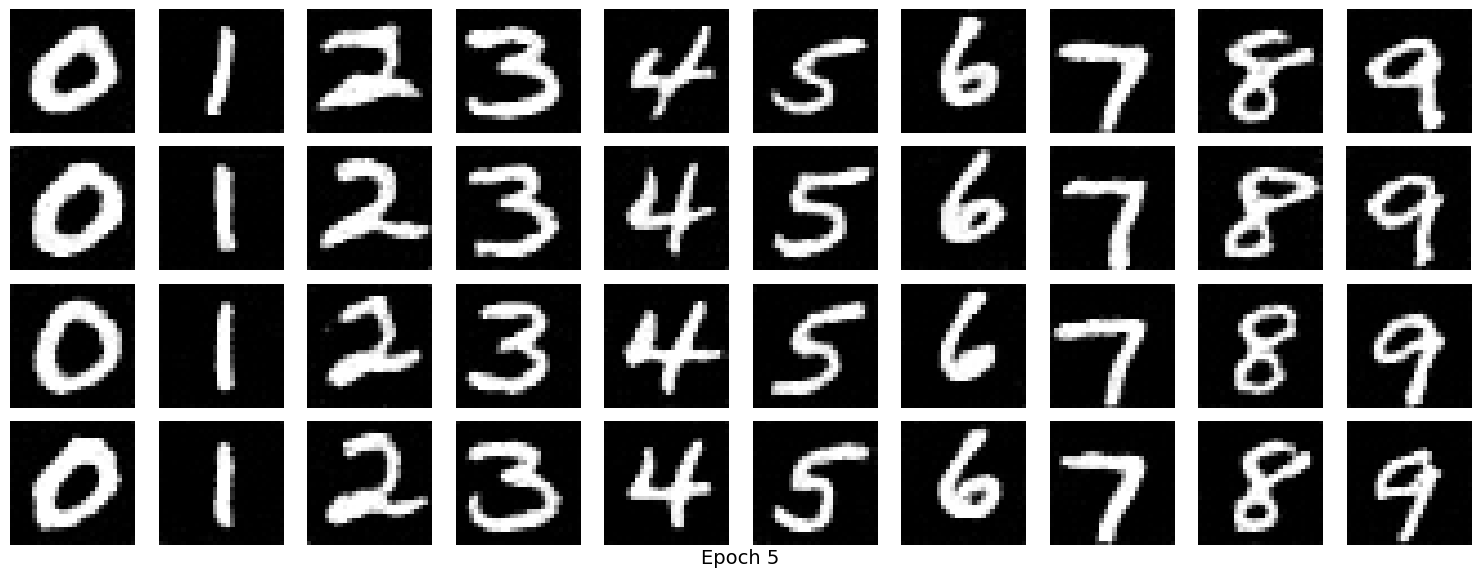

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# Sampling from the UNet
# ===== your code here! ====
# Sampling from the class-conditioned UNet at different epochs
guidance_scale = 5.0

# c: 4 samples per digit (0-9) -> 40 samples total, ordered by digit
c = torch.tensor([d for d in range(10) for _ in range(4)], device=device)  # [0,0,0,0,1,1,1,1,...,9,9,9,9]

for epoch in {1, 5, 10}:
    ckpt_path = os.path.join(checkpoint_dir_class, f'class_fm_epoch_{epoch}.pt')
    ckpt = torch.load(ckpt_path)
    unet_class.load_state_dict(ckpt['model'])

    samples, _ = class_fm_sample(
        unet_class,
        c=c,
        img_wh=(28, 28),
        num_ts=num_ts,
        guidance_scale=guidance_scale,
        seed=0,
    )  # (40, 1, 28, 28)

    # Display as 4 rows x 10 cols (each col = one digit class)
    # Reorder from [0,0,0,0,1,1,...] to row-major [0,1,2,...,9, 0,1,2,...,9,...]
    samples_grid = samples.reshape(10, 4, 1, 28, 28).permute(1, 0, 2, 3, 4)  # (4, 10, 1, 28, 28)

    fig, axes = plt.subplots(4, 10, figsize=(15, 6))
    for row in range(4):
        for col in range(10):
            axes[row][col].imshow(samples_grid[row][col].cpu().squeeze().clamp(0, 1), cmap='gray')
            axes[row][col].axis('off')

    plt.suptitle(f'Epoch {epoch}', y=0.02, fontsize=14)
    plt.tight_layout()
    plt.savefig(f'2.6_class_fm_samples_epoch_{epoch}.png', bbox_inches='tight', dpi=150)
    plt.show()
    files.download(f'2.6_class_fm_samples_epoch_{epoch}.png')
# ===== end of code ====

# Can we get rid of the annoying learning rate scheduler?
We did not use a learning rate scheduler in our training pipeline. We used a fixed Adam optimizer with learning rate 1e-4 throughout all epochs. This kept the training simple while still achieving good results, as evidenced by the stable loss curves and quality of generated samples. The fixed learning rate of 1e-4 was sufficient to converge without any additional scheduling strategy.